# Singapore NEA Dengue Surveillance & Vector Control

This notebook demonstrates how to access dengue data from the Singapore **National Environment Agency (NEA)** via [data.gov.sg](https://data.gov.sg/).

Singapore is a **world reference in dengue vector control**.  
The NEA publishes both historical case counts and real-time geo-located data on clusters and breeding habitats — ideal for benchmarking against Brazilian models.

**Data Sources:**
- **[Weekly Dengue/DHF cases](https://data.gov.sg/datasets/d_ac1eecf0886ff0bceefbc51556247015/view)** (2014–2018)
- **[Dengue Clusters](https://data.gov.sg/datasets/d_dbfabf16158d1b0e1c420627c0819168/view)** (real-time, geo-located)
- **Aedes Mosquito Breeding Habitats** (by NEA region)

**Coverage:**
- **Geographic:** National + NEA operational regions (Central, South East, South West …)
- **Temporal:** 2014–2018 (weekly cases); real-time (clusters & habitats)

**Requirements:**
```bash
pip install pandas matplotlib seaborn geopandas epidatasets
```

## 1. Setup and Imports

In [1]:
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)

print(f"Imports completed. {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Imports completed. 2026-06-22 15:41


## 2. Initialize the Accessor

In [2]:
from epidatasets.sources.singapore_nea import SingaporeNEAAccessor

nea = SingaporeNEAAccessor()

print(f"Source      : {nea.source_name}")
print(f"Description : {nea.source_description}")
print(f"Portal      : {nea.source_url}")

Source      : singapore_nea
Description : Dengue surveillance and vector-control data from the Singapore National Environment Agency (NEA) via data.gov.sg: weekly dengue/DHF case counts, active dengue clusters, regional case data, and Aedes mosquito breeding habitat detections.
Portal      : https://data.gov.sg/collections/1441/view


In [3]:
countries = nea.list_countries()
print(countries.to_string(index=False))

country_code country_name
          SG    Singapore


### NEA operational regions

Singapore is divided into five NEA districts for vector-control operations.

In [4]:
regions = nea.list_regions()
display(regions)

,region,has_cases_data,has_habitats_data
0,Central,True,True
1,North East,False,False
2,North West,False,True
3,South East,True,True
4,South West,True,True


## 3. Active Dengue Clusters (Real-Time)

A **dengue cluster** is an area with two or more dengue cases within 150 m and 21 days.  The NEA publishes active clusters as geo-located polygons with case counts and inspection details.

In [5]:
clusters = nea.get_dengue_clusters()
print(f"Active clusters: {len(clusters)}")
display(clusters[['locality', 'case_size', 'longitude', 'latitude']].head(10))

Active clusters: 16


,locality,case_size,longitude,latitude
0,Bishan St 22 (Blk 236) / Bishan St 23 (Blk 228...,3,103.845940,1.358388
1,"Ang Mo Kio Ave 4 (Blk 615, 619)",2,103.839091,1.378982
2,"Jln Bangau, Jarak, Jitong, Lebat Daun, Lekub, ...",24,103.870150,1.382599
3,"Countryside Rd, Walk / Lentor Ave, Ter / Lento...",51,103.836564,1.390437
4,Dedap Pl / Seletar Rd / Seletar Rd (Seletar Pa...,6,103.868475,1.386697
5,"Mimosa Cres, Pl, Ter, View",6,103.860875,1.385333
6,Braddell Hill (Braddell View),8,103.841466,1.341711
7,Tamarind Rd / Tamarind Rd (Serenity Pk),3,103.859644,1.389035
8,"Neram Rd / Nim Cres, Dr, Green / Saraca Hill, ...",20,103.865679,1.383387
9,Hougang Ave 1 (Blk 174C) / Hougang St 13 (Blk ...,3,103.888184,1.348619


In [6]:
summary = nea.get_cluster_summary()
display(summary)

,total_clusters,total_cases,mean_cluster_size,max_cluster_size,clusters_with_construction_sites
0,16,152,9.5,51,0


### Cluster size distribution

Most clusters are small (< 10 cases), but a few large hotspots can drive the majority of transmission.

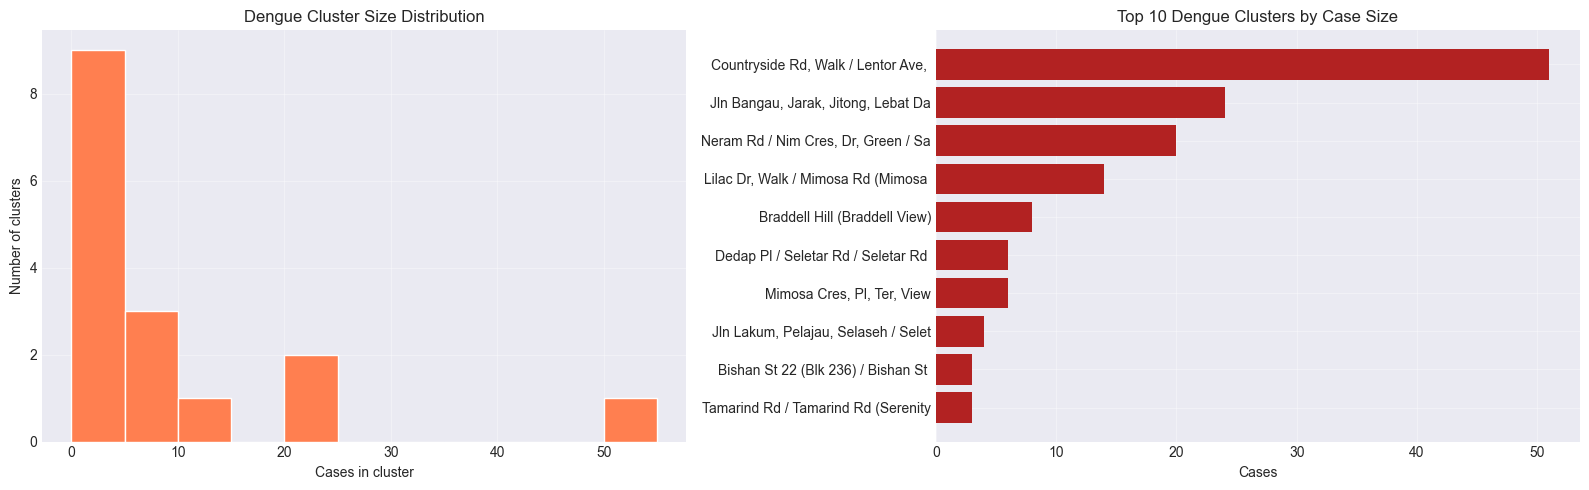

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(clusters['case_size'], bins=range(0, int(clusters['case_size'].max()) + 5, 5),
             color='coral', edgecolor='white')
axes[0].set_title('Dengue Cluster Size Distribution')
axes[0].set_xlabel('Cases in cluster')
axes[0].set_ylabel('Number of clusters')

top10 = clusters.nlargest(10, 'case_size')
axes[1].barh(top10['locality'].str[:35][::-1], top10['case_size'][::-1],
             color='firebrick')
axes[1].set_title('Top 10 Dengue Clusters by Case Size')
axes[1].set_xlabel('Cases')

plt.tight_layout()
plt.show()

### Cluster map

Plotting cluster centroids on a simple scatter map of Singapore.

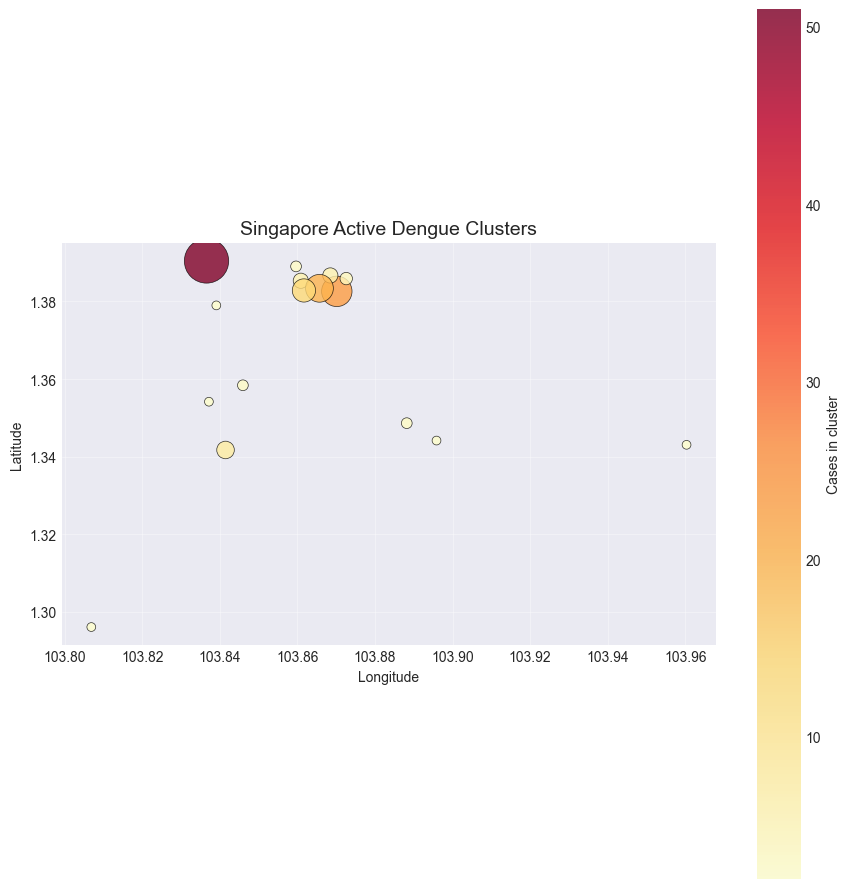

In [8]:
fig, ax = plt.subplots(figsize=(9, 9))
scatter = ax.scatter(
    clusters['longitude'], clusters['latitude'],
    s=clusters['case_size'] * 20,
    c=clusters['case_size'], cmap='YlOrRd',
    edgecolors='black', linewidths=0.5, alpha=0.8,
)
plt.colorbar(scatter, label='Cases in cluster')
ax.set_title('Singapore Active Dengue Clusters', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 4. Aedes Mosquito Breeding Habitats

The NEA conducts inspections and geo-locates detected Aedes breeding habitats.  These are published per region as GEOJSON.

In [9]:
habitats = nea.get_breeding_habitats(region='Central')
print(f"Breeding habitats detected (Central): {len(habitats)}")
display(habitats[['area_name', 'longitude', 'latitude']].head(10))

Breeding habitats detected (Central): 99


,area_name,longitude,latitude
0,Aedes Mosquito Breeding Habitats : 1,103.849255,1.317556
1,Aedes Mosquito Breeding Habitats : 1,103.798936,1.308512
2,Aedes Mosquito Breeding Habitats : 1,103.824096,1.294042
3,Aedes Mosquito Breeding Habitats : 1,103.820501,1.299468
4,Aedes Mosquito Breeding Habitats : 1,103.856443,1.310321
5,Aedes Mosquito Breeding Habitats : 1,103.858240,1.312129
6,Aedes Mosquito Breeding Habitats : 1,103.824096,1.284998
7,Aedes Mosquito Breeding Habitats : 3,103.863632,1.303086
8,Aedes Mosquito Breeding Habitats : 3,103.865429,1.303086
9,Aedes Mosquito Breeding Habitats : 1,103.863632,1.304894


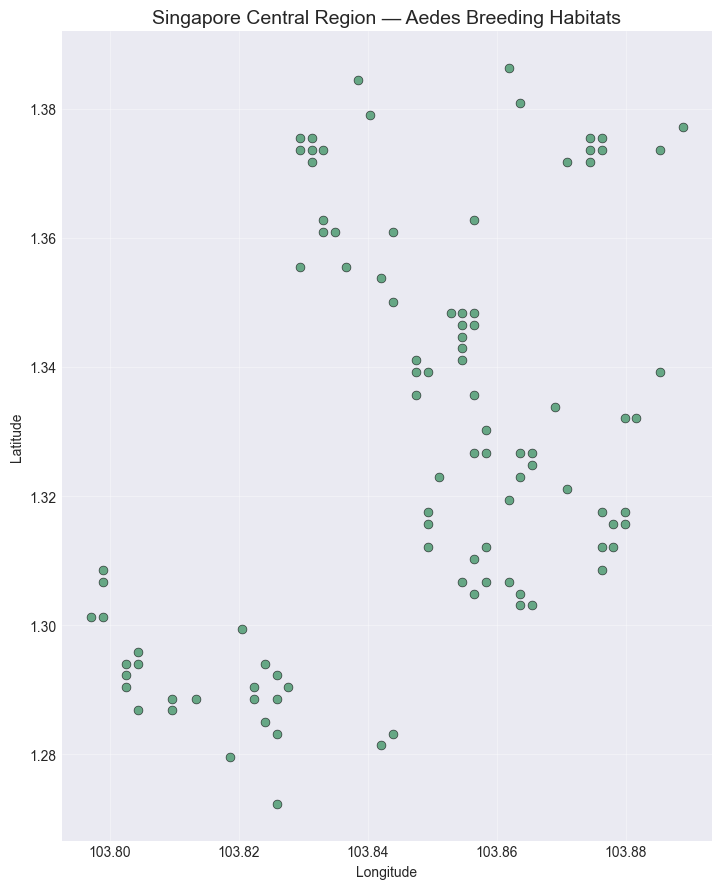

In [10]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(
    habitats['longitude'], habitats['latitude'],
    s=40, c='seagreen', edgecolors='black', linewidths=0.5, alpha=0.7,
)
ax.set_title('Singapore Central Region — Aedes Breeding Habitats', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 5. Historical Weekly Dengue / DHF Cases

Weekly dengue and Dengue Haemorrhagic Fever (DHF) case counts (2014–2018).

In [11]:
weekly = nea.get_weekly_cases()
print(f"Weekly records: {len(weekly)}")
print(f"Years: {sorted(weekly['year'].dropna().unique().tolist())}")
display(weekly.head(10))

Weekly records: 530
Years: [2014, 2015, 2016, 2017, 2018]


,year,eweek,type_dengue,number
0,2014,1,DHF,1
1,2014,1,Dengue,436
2,2014,2,DHF,0
3,2014,2,Dengue,479
4,2014,3,DHF,0
5,2014,3,Dengue,401
6,2014,4,DHF,0
7,2014,4,Dengue,336
8,2014,5,DHF,0
9,2014,5,Dengue,234


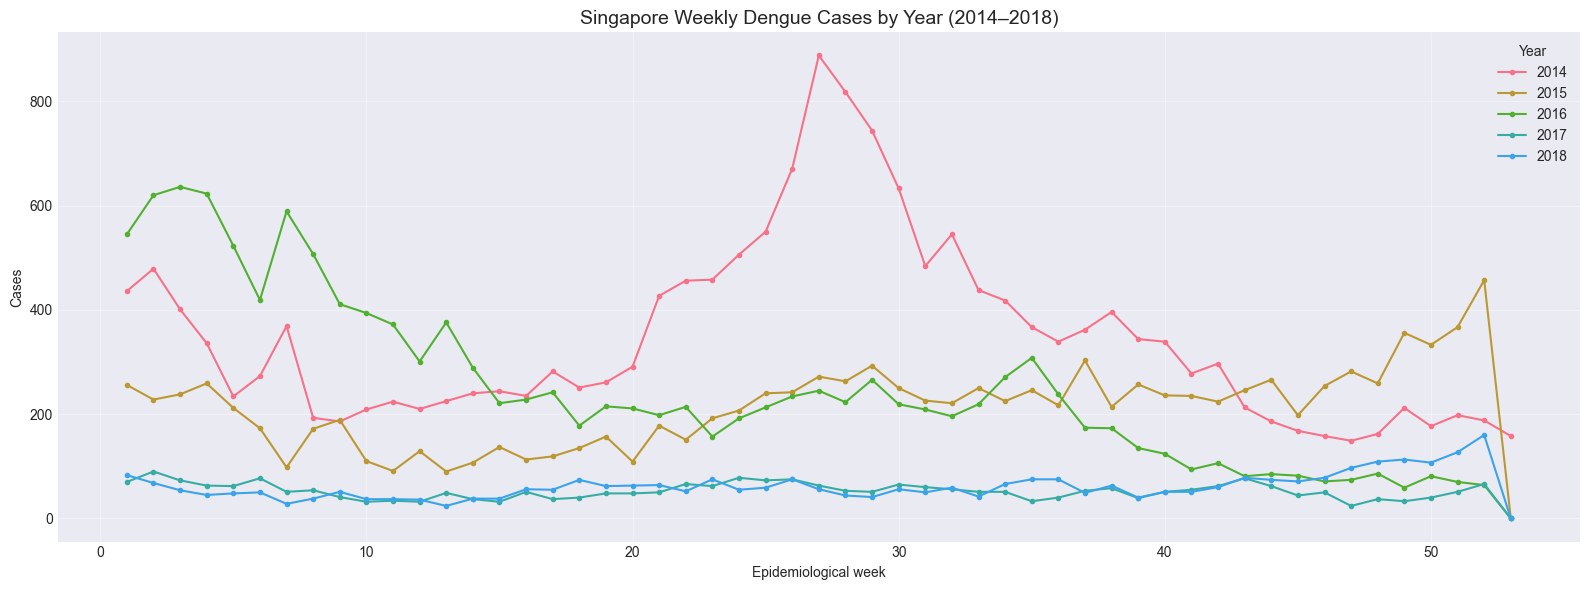

In [12]:
fig, ax = plt.subplots(figsize=(16, 6))
for year, grp in weekly[weekly['type_dengue'] == 'Dengue'].groupby('year'):
    ax.plot(grp['eweek'], grp['number'], marker='.', label=str(int(year)))

ax.set_title('Singapore Weekly Dengue Cases by Year (2014–2018)', fontsize=14)
ax.set_xlabel('Epidemiological week')
ax.set_ylabel('Cases')
ax.legend(title='Year')
plt.tight_layout()
plt.show()

### Dengue vs Dengue Haemorrhagic Fever

DHF (severe dengue) is far less common than classic dengue fever.

,year,type_dengue,number
0,2014,DHF,20
1,2014,Dengue,18306
2,2015,DHF,12
3,2015,Dengue,11282
4,2016,DHF,24
5,2016,Dengue,13061
6,2017,DHF,17
7,2017,Dengue,2750
8,2018,DHF,26
9,2018,Dengue,3257


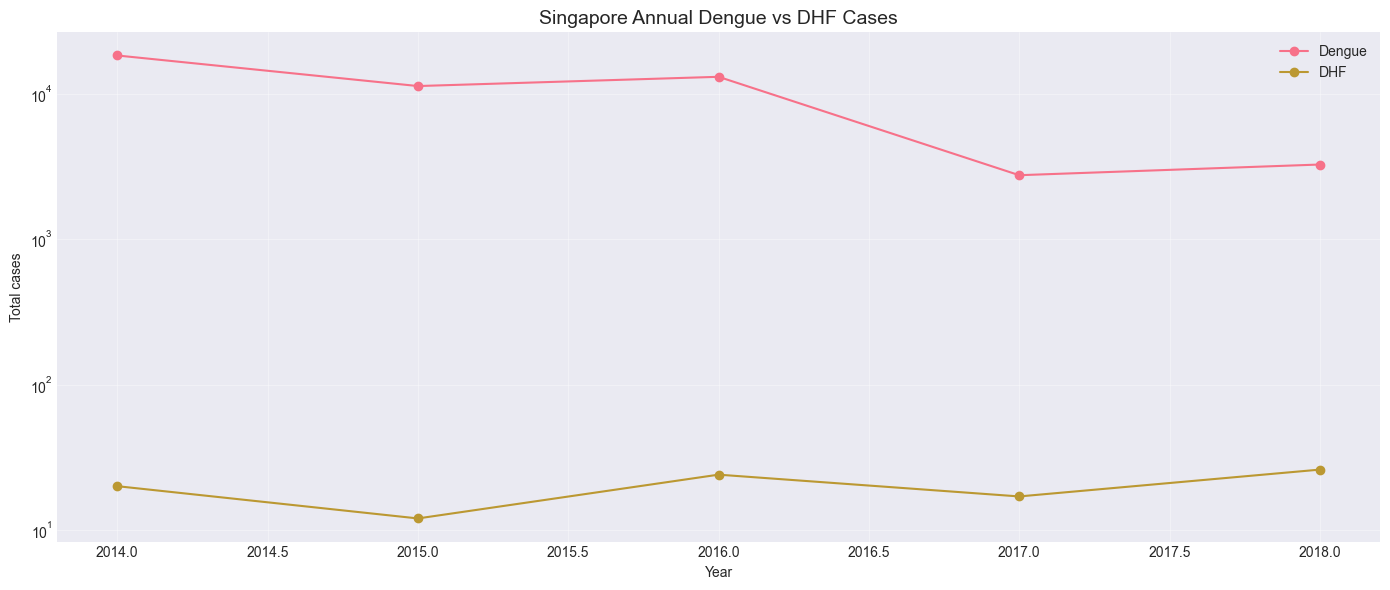

In [13]:
annual = nea.get_weekly_summary(by='year')
display(annual)

fig, ax = plt.subplots()
for dtype in ['Dengue', 'DHF']:
    sub = annual[annual['type_dengue'] == dtype]
    ax.plot(sub['year'], sub['number'], marker='o', label=dtype)
ax.set_title('Singapore Annual Dengue vs DHF Cases', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Total cases')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Summary

| Method | Description |
|--------|-------------|
| `get_weekly_cases(years)` | Historical weekly Dengue/DHF counts (2014–2018) |
| `get_dengue_clusters(min_cases)` | Active geo-located clusters (real-time) |
| `get_breeding_habitats(region)` | Aedes breeding habitat detections by region |
| `get_regional_cases(region)` | Geo-located case clusters per NEA district |
| `get_cluster_summary()` | Summary stats of active clusters |
| `list_regions()` | NEA operational regions |

**Related notebooks:**
- [Singapore MOH Infectious Disease](26_Singapore_MOH_Infectious_Disease.ipynb) — broader weekly infectious disease bulletin.
- [InfoDengue Brazilian Arbovirus Surveillance](18_InfoDengue_Brazilian_Arbovirus_Surveillance.ipynb) — compare with Brazilian dengue data.
- [Pakistan NIH Surveillance](23_Pakistan_NIH_Surveillance.ipynb) — another Asian dengue-endemic country.